<a href="https://colab.research.google.com/github/thethien8a/Sentiment-Analysis-Vietnamese/blob/m%E1%BA%A1nh/phoBert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# !pip install emoji
# !pip install underthesea
import torch
import requests
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score
from underthesea import word_tokenize
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Tên mô hình
model_name = "wonrax/phobert-base-vietnamese-sentiment"

# Load tokenizer & model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

In [24]:
# ---- ĐỌC DATA -----
raw_url = 'https://github.com/thethien8a/Sentiment-Analysis-Vietnamese/raw/main/comment_data/Tram_dung_chan_Jack_shuffled.xlsx'
df_cmt = pd.read_excel(raw_url)
df_cmt = df_cmt[['textDisplay', 'label']]
df_cmt.head()

,textDisplay,label
0,Đừng dối lòng phủ nhận tài năng của Jack. Nhìn...,2.0
1,mình là tài xế chạy grab gần 8 năm chưa bao gi...,2.0
2,Sky qua ủng hộ Jack \nChúc dự án này thành côn...,2.0
3,"Không uổn công tui cày từ 5 giờ sáng tới giờ, ...",2.0
4,Đa số nghệ sĩ trong showbiz hiện giờ á toàn qu...,2.0


## Tạo từ điển viết tắt và Tạo hàm

In [31]:
TEENCODE_DICT = {
    'ko': 'không', 'k': 'không', 'kh': 'không', 'bt': 'biết',
    'dc': 'được', 'đc': 'được', "ak":"à", "àh":"à",
    "uk":"ừ","uh":"ừ", "cmnl":"con mẹ nó luôn",
    'ad': 'admin', 'ntn': 'như thế nào',
    'v': 'vậy', 'r': 'rồi', "qtr":"quá trời",
    'cx': 'cũng',
    'ib': 'inbox',
    'rep': 'trả lời',
    'mn': 'mọi người',
    'cmt': 'comment',
    'b': 'bạn',
    "tr":"trời",
    'e': 'em',
    'a': 'anh',
    "ng":"người", "lm":"làm", "cầu đặc": "đầu cặc", "kẹc":"cặc", "đ":"đéo", "gđ":"gia đình", "cằk":"cặc","cặk":"cặc", 'okela':'ok', "djt":"địt",
    "trây":"jack",  "bn":"bao nhiêu","bnh":"bao nhiêu", "cmm":"con mẹ","cm":"chúng mày","clm":"cái lồn má", 'vc':'vãi cả', 'cc':'cục cứt', 'loz':'lồn', 'l':'lồn', "lol":"lồn","lòn":"lồn", "lôn":"lồn",
    'vl':'vãi lồn',"vcl":"vãi cả lồn","vkl":"vãi cả lồn", "đcm":"địt con mẹ","đm":"địt mẹ","đcmm":"địt con mẹ","đcmmm":"địt con mẹ", "đb":"đầu buồi",
    'deo':'đéo','dell':'đéo', 'vcc':"vãi cả cứt", "occho":"óc chó", "t":"tôi", "chx":"chưa", "xg":"xong",
    "vcd":"vãi cả đái","vcđ":"vãi cả đái",
    "ae":"anh em", "j":"gì",
    "soll":"son","sol":"son",
    "vaiz":"vãi",
    "mn":"mọi người","mng":"mọi người",
    "bth":"bình thường",
    "m":"mày",
    "cm":"chúng mày",
    "ch":"chưa",
    "vs":"với",
    "sv":"súc vật",
    "c":"cứt",
    "t.o.p":"top",
    "ncc":"như cục cứt",
    "dit":"địt","djt":"địt",
    "hth":"hiếu thứ hai",
    "qc":"quảng cáo",
    "vn":"việt nam", "vaiz":"vãi",
    "r":"rồi", "nge":"nghe", "tiktok":"tik tok", "ytb":"youtube", "fb":"facebook", "vcut":"vãi cứt","shit":"cứt", "fl":"follow"
}

EMOJI_DICT = {
    "😢":" bieu_tuong_buon ",
    "🎉":" bieu_tuong_chuc_mung ",
    "❤":" bieu_tuong_trai_tim ",
    "🤣":" bieu_tuong_mat_cuoi ", "😂":" bieu_tuong_mat_cuoi ",
    "😭":" bieu_tuong_khoc ",
    "🔥":" bieu_tuong_chay ",
    "💩":" bieu_tuong_cut ",
    "🥰":" bieu_tuong_yeu_thuong ",
    "😮":" bieu_tuong_ngac_nhien ",
    "😅":" bieu_tuong_lo_lang ",
    "<3":" bieu_tuong_trai_tim "
}

STOP_WORDS = set()

raw_url = 'https://github.com/thethien8a/Sentiment-Analysis-Vietnamese/raw/main/vietnamese-stopwords-dash.txt'
response = requests.get(raw_url)

# Kiểm tra xem yêu cầu có thành công không (status code 200 là OK)
if response.status_code == 200:
    lines = response.text.splitlines()
    for line in lines:
        word = line.strip()
        if word:
            STOP_WORDS.add(word)
        else:
          break
    print(f"Tải xong {len(STOP_WORDS)} STOP_WORDS")

Tải xong 1942 STOP_WORDS


In [34]:
def preprocessing_basic(text):
  text = text.lower()
  text = re.sub(r'http\S+','',text)
  text = re.sub(r'<.*?>', '', text)
  text = text.strip()
  text = text.replace("t o p","top").replace("tốp","top")
  text = text.replace("v i e w","view").replace("c à y","cày")
  text = text.replace("đốn lòm","đóm lồn").replace("đốm lòn","đóm lồn")
  return text

def replace_teencode(text,teencode_dict):
  words = text.split()
  for idx,each_word in enumerate(words):
    if each_word in teencode_dict:
      words[idx] = teencode_dict[each_word]
  return ' '.join(words)

def exception_stop_words(text):
  return text.replace("hay","hayy")

def replace_emoji(text,emoji_dict):
  for emoji, word in emoji_dict.items():
      text = text.replace(emoji, word)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

def remove_stop_words(text,stop_words):
  words = text.split()
  filtered_words = [word for word in words if word not in STOP_WORDS]
  return ' '.join(filtered_words)


def keep_chars(text):
  vietnamese_chars = 'àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ'
  # Whitelist bao gồm: chữ cái a-z, chữ cái tiếng Việt, và dấu gạch dưới
  allowed_chars = vietnamese_chars + 'a-z_'
  # Tạo pattern để tìm các ký tự KHÔNG thuộc whitelist (và cũng không phải khoảng trắng)
  unwanted_chars_pattern = re.compile(f'[^{allowed_chars}\s]')
  text = unwanted_chars_pattern.sub('', text)
  text = re.sub(r'\s+',' ',text)
  text = text.strip()
  return text

def preprocess_comment(text):
    global TEENCODE_DICT
    global EMOJI_DICT
    global STOP_WORDS

    text = preprocessing_basic(text)
    text = replace_teencode(text, TEENCODE_DICT)
    text = replace_emoji(text,EMOJI_DICT)
    text = keep_chars(text)

    # Tách từ cho có nghĩa
    text = word_tokenize(text, format="text")
    text = exception_stop_words(text)
    text = remove_stop_words(text,STOP_WORDS)
    return text

## Tiền xử lý

In [35]:
# Lọc trùng bình luận (tránh seeding)
df_cmt = df_cmt.drop_duplicates(subset=['textDisplay'], keep='first')
df_cmt["textDisplay"] = df_cmt["textDisplay"].fillna("").apply(preprocess_comment)

In [37]:
# Thay nhãn
df_cmt['label'] = df_cmt['label'].replace({
    0.0: 'NEG',
    1.0: 'NEU',
    2.0: 'POS'
})

In [38]:
df_cmt.head()

,textDisplay,label
0,đừng dối_lòng phủ_nhận tài_năng jack xung_quan...,POS
1,tài_xế chạy grab comment like may_mắn hôm_nay ...,POS
2,sky ủng_hộ jack_chúc dự_án thành_công rực_rỡ n...,POS
3,uổn_công tui cày thứ_vô cơ_quan soạn hồ_sơ sáp...,POS
4,đa_số nghệ_sĩ showbiz hiện_giờ á_toàn clip con...,POS


## Huấn luyện

## Dự đoán

In [39]:
len(df_cmt)

40191

In [40]:
# Thử với 150 comment 0<POS<2000; 2220<NEU<3000; 3300<NEG)
df_cmt = pd.concat([
    df_cmt.iloc[1000:1050],
    df_cmt.iloc[2220:2270],
    df_cmt.iloc[3300:3350]
]).reset_index(drop=True)

# Shuffle
df_cmt = df_cmt.sample(frac=1, random_state = 42).reset_index(drop=True)
df_cmt.head(10)

,textDisplay,label
0,m lận,NEU
1,thương nhạc jack hayy,POS
2,bựa ah_chây đi đạo,NEG
3,hong,NEU
4,hy_vọng anti đầu bớt sân si_nha đừng sợ quê,NEU
5,fan xưa giở ca hayy ủng_hộ,POS
6,antifan,NEU
7,bình_thường khen công_nghiệp,NEG
8,xuyên đêm,NEU
9,nhạc ngục tù_tình_yêu nha bieu_tuong_mat_cuoi ...,NEU


In [41]:
comment_list = df_cmt['textDisplay'].fillna('').tolist()
comment_list[:5]

['m lận',
 'thương nhạc jack hayy',
 'bựa ah_chây đi đạo',
 'hong',
 'hy_vọng anti đầu bớt sân si_nha đừng sợ quê']

In [42]:
# Tạo pipeline cho sentiment analysis
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)
results = sentiment_pipeline(comment_list)

# --- THÊM KẾT QUẢ VÀO DATAFRAME VÀ LƯU LẠI ---
labels = [result['label'] for result in results]
scores = [result['score'] for result in results]
results[:5]

# Tạo các cột mới trong DataFrame để lưu kết quả
df_cmt['sentiment_label'] = labels
df_cmt['sentiment_score'] = scores

Device set to use cpu


In [43]:
df_cmt.iloc[:,:]

,textDisplay,label,sentiment_label,sentiment_score
0,m lận,NEU,NEU,0.899735
1,thương nhạc jack hayy,POS,POS,0.991537
2,bựa ah_chây đi đạo,NEG,NEU,0.835852
3,hong,NEU,NEU,0.868473
4,hy_vọng anti đầu bớt sân si_nha đừng sợ quê,NEU,NEU,0.847460
...,...,...,...,...
145,ace,NEU,POS,0.826873
146,bố thằng ăn_cắp nhạc,NEG,NEG,0.969570
147,mê đỡ nổi mê giọng hát jack cố_gắng nè ủng_hộ ...,POS,POS,0.992967
148,top,NEU,NEU,0.639353


## ĐÁNH GIÁ KẾT QUẢ

ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH
Accuracy (Độ chính xác tổng thể): 51.33%

Classification Report:

              precision    recall  f1-score   support

         NEG       0.55      0.62      0.58        50
         NEU       0.47      0.30      0.37        50
         POS       0.50      0.62      0.55        50

    accuracy                           0.51       150
   macro avg       0.51      0.51      0.50       150
weighted avg       0.51      0.51      0.50       150


Confusion Matrix:


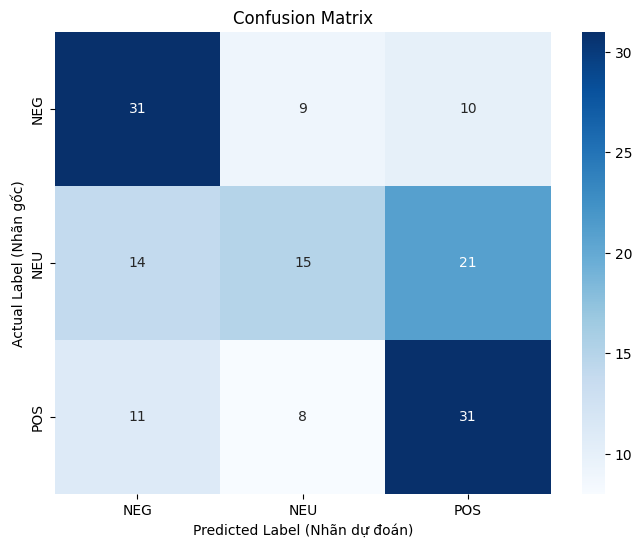

In [45]:
y_true = df_cmt['label']
y_pred = df_cmt['sentiment_label']

# Xác định tất cả các nhãn có thể có để đảm bảo thứ tự nhất quán
class_names = ['NEG', 'NEU', 'POS']

# --- BƯỚC 2: TÍNH TOÁN VÀ IN CÁC CHỈ SỐ ---
print("ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH\n" + "="*30)

# 2.1. Độ chính xác tổng thể (Accuracy)
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy (Độ chính xác tổng thể): {accuracy:.2%}\n")

# 2.2. Báo cáo phân loại chi tiết (Classification Report)
print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# --- BƯỚC 3: VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label (Nhãn gốc)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()

In [46]:
# --- BƯỚC 4 (TÙY CHỌN): XEM LẠI CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI ---
print("\nCÁC TRƯỜNG HỢP DỰ ĐOÁN SAI:\n" + "="*30)
misclassified = df_cmt[df_cmt['label'] != df_cmt['sentiment_label']]
print(misclassified[['textDisplay', 'label', 'sentiment_label']])


CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI:
                                           textDisplay label sentiment_label
2                                   bựa ah_chây đi đạo   NEG             NEU
6                                              antifan   NEU             NEG
7                         bình_thường khen công_nghiệp   NEG             POS
8                                            xuyên đêm   NEU             POS
9    nhạc ngục tù_tình_yêu nha bieu_tuong_mat_cuoi ...   NEU             POS
..                                                 ...   ...             ...
140                                         dìm nổi_sợ   NEU             NEG
141  lạ hôm_nay nghề chửi thuê mxh trời oiiiiiviệc ...   NEU             NEG
142              nhạc trung_mà ghi_nhạc trung_lời việt   NEG             POS
143                    nhạc đéo cảm_súc nhố nhăng quad   NEG             NEU
145                                                ace   NEU             POS

[73 rows x 3 columns]
